In [ ]:
from pathlib import Path
from metasmith.python_api import Agent, Source, SshSource, Std, DataInstanceLibrary, TransformInstanceLibrary
from metasmith.python_api import Resources, Size, Duration
from metasmith.python_api import ContainerRuntime

dtypes, containers, transforms = Std()
base_dir = Path("./cache")

agent_home = Source.FromLocal((base_dir/"local_home").resolve())
# agent_home = SshSource(host="sockeye", path=Path("/scratch/st-shallam-1/pwy_group/metasmith_home")).AsSource()
# agent_home = SshSource(host="fir", path=Path("/scratch/phyberos/metasmith")).AsSource()
# agent_home = SshSource(host="chamois", path=Path("/home/tliu/metasmith")).AsSource()
smith = Agent(
    home = agent_home,
    runtime=ContainerRuntime.DOCKER
    # runtime=ContainerRuntime.APPTAINER,
)
smith.Deploy()

In [2]:
x = TransformInstanceLibrary('/home/tony/workspace/tools/MetasmithLibraries/transforms/assembly')
x.Save()
x.AddStub("_template")

TransformInstance(protocol=<function protocol at 0x76b4e3baf920>, model={example_input-metasmith}->{example_output-metasmith}, output_signature={(D:example_output-metasmith): 'output.txt'}, group_by=(D:example_input-metasmith), name='_template', resources=None, batch_size=1, _key='WLNiA', _hash=55649918432055161679952601694998253164818325507031624413097730507639391018342)

In [13]:
for k in dtypes.types:
    if "accession" not in k: continue
    print(k)

long_reads_accession
short_reads_accession


In [14]:
for k in dtypes.types:
    if "annotations" not in k: continue
    print(k)

bakta_annotations
busco_annotations
cazy_annotations
functional_annotations
kofamscan_annotations


In [15]:
in_dir = base_dir/"std_assembly_data.xgdb"
inputs = DataInstanceLibrary(in_dir)
# inputs.AddItem("./lr_ss10.fastq", "std::long_reads")
# inputs.AddItem("./cb2a.acc", "std::long_reads_accession")
inputs.AddItem("./epi300.acc", "std::long_reads_accession")
# inputs.AddItem("./SRR36161492.acc", "std::long_reads_accession")
inputs.Save()

In [16]:
for x in inputs.Iterate():
    print(x)

(PosixPath('epi300.acc'), 'std::long_reads_accession', <{data:Accession number associated with long reads,format:Plaintext file}:4HMb09gR>)


In [17]:

task = smith.GenerateWorkflow(
    samples=[inputs],
    resources=[containers],
    transforms=[transforms],
    targets=[
        # dtypes["short_reads_assembly"],
        # dtypes["assembly"],
        dtypes["busco_annotations"],
        # dtypes["hybrid_assembly"],
        # dtypes["bakta_annotations"].WithLineage([dtypes["hybrid_assembly"]]),
        # dtypes["functional_annotations"].WithLineage([dtypes["long_reads_assembly"]]),
        # dtypes["functional_annotations"].WithLineage([dtypes["hybrid_assembly"]]),
        # dtypes["per_contig_coverage"].WithLineage([dtypes["short_reads_assembly"]]),
    ],
    max_refine=256,
)
# for s in task.plans[0][0].steps:
#     print(s.order, s.transform.name)
#     for u in s.uses:
#         print(f"  {u.dtype.key} {u.dtype_name}")
#     print()

sum(len(p.steps) for g in task.plans for p in g)

8

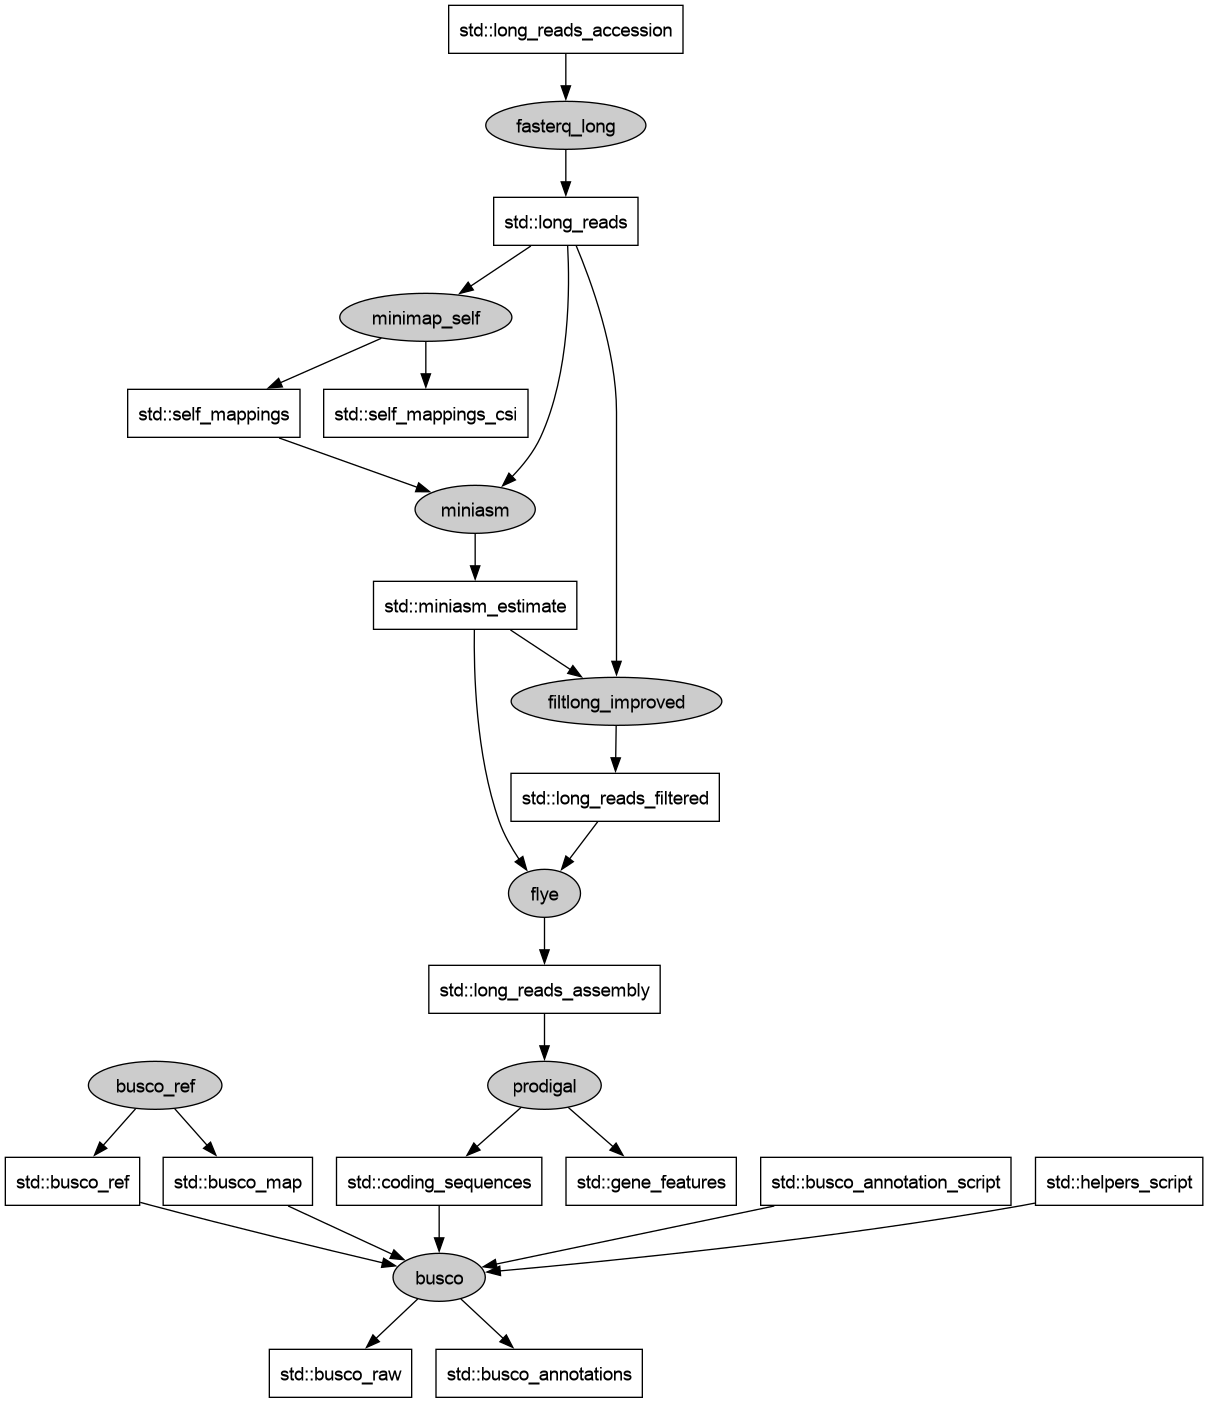

In [18]:
from IPython.display import Image
base_dir = Path("./cache")
dagf = Path(base_dir / f"dag_std_assembly")
task.plans[0][0].RenderDAG(dagf, format="png")
Image(filename=f"{dagf}.png")

In [19]:
# just switch to file based relay in tmp dir...

In [20]:
smith.StageWorkflow(task, on_exist="clear")

2025-12-03_14-16-29  | staging workflow [hY1Zdufz]
2025-12-03_14-16-29  | connecting to deployed agent
2025-12-03_14-16-29  | starting relay service
 | > 2025-12-03_14-16-30  | starting watcher relay at [/tmp/msm_XPS-laptop_tony] with cwd [/home/tony/workspace/tools/Metasmith/main/local_mock/cache/local_home]
 | > 2025-12-03_14-16-30  | pid [114733]
 | > 2025-12-03_14-16-30  | success
2025-12-03_14-16-30 W| task already staged at [/home/tony/workspace/tools/Metasmith/main/local_mock/cache/local_home/runs/hY1Zdufz]
2025-12-03_14-16-30 W| clearing previously staged task
2025-12-03_14-16-30  | sending metadata for workflow [hY1Zdufz]
2025-12-03_14-16-32  | staging
 | > including dev binds
 | > binds [ --mount type=bind,source=./,target=/ws --mount type=bind,source=/tmp,target=/tmp --mount type=bind,source=/home/tony/workspace/tools/Metasmith/main/local_mock/cache/local_home,target=/msm_home --mount type=bind,source=/home/tony/.globus,target=/home/tony/.globus --mount type=bind,source=/hom

In [ ]:
for path, tr in transforms.IterateTransforms():
    print(tr.name)

annotations
bakta
bakta_db_full
bedtools_genomcov
busco
busco_ref
cazy
cazy_ref
fasterq_long
fasterq_short
fastqc
filtlong_improved
flye
interleave_pe_reads_seqtk
kofamscan
kofamscan_ko_list
kofamscan_profiles
longqc
megahit
miniasm
minimap
minimap_self
pilon
prodigal
trimmomatic


In [2]:
import platform

platform.system()

'Linux'

In [23]:
# with open("./cache/slurm_account_sockeye") as f:
with open("./cache/slurm_account_fir") as f:
    SLURM_ACCOUNT = f.read()

smith.RunWorkflow(
    task,
    # params=dict(
    #     slurmAccount=SLURM_ACCOUNT,
    # ),
    # config_file=smith.GetNxfConfigPresets()["slurm"],
    config_file=smith.GetNxfConfigPresets()["local"],
    resource_overrides={
        "all": Resources(
            cpus=8,
            memory=Size.GB(7),
        ),
        transforms["busco_ref"]: Resources(
            cpus=2,
        ),
        transforms["fasterq_long"]: Resources(
            cpus=2, 
        ),
    }
)

2025-12-03_14-17-41  | connecting to deployed agent
2025-12-03_14-17-41  | starting relay service
 | > 2025-12-03_14-17-41 W| relay server already running at [/home/tony/workspace/tools/Metasmith/main/local_mock/cache/local_home/relay/XPS-laptop]
2025-12-03_14-17-42  | sending config and params
2025-12-03_14-17-42  | triggering execution of [hY1Zdufz]
 | > start time was [2025-12-03_14-17-42]
2025-12-03_14-17-42  | closing connection
